# Student placement prediction

Can we predict whether a student is placed through campus recruitment from their academic record?

This notebook explores the [Factors Affecting Campus Placement](https://www.kaggle.com/benroshan/factors-affecting-campus-placement) dataset (215 students), compares several classifiers, and explains the model that the Streamlit app serves.

Run it from the repository root so that `import placement` works:

```bash
pip install -r requirements-dev.txt
jupyter notebook student_placement_prediction.ipynb
```

**Method in one paragraph.** With only 215 rows, a single train/test split leaves about 43 test students, and one student is worth more than two accuracy points. So every model is scored with repeated stratified 5-fold cross-validation, and scaling and encoding live *inside* a scikit-learn `Pipeline` so nothing from the held-out fold leaks into training.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
from sklearn.model_selection import (
    RepeatedStratifiedKFold,
    StratifiedKFold,
    cross_val_predict,
    cross_val_score,
    cross_validate,
)
from sklearn.svm import SVC

from placement.pipeline import (
    CATEGORICAL_FEATURES,
    CV_FOLDS,
    CV_REPEATS,
    FEATURE_LABELS,
    FEATURES,
    NUMERIC_FEATURES,
    RANDOM_STATE,
    build_pipeline,
    candidate_models,
    explain_prediction,
    load_data,
    load_raw,
)
from placement.train import SCORING, choose_model, fit_final

sns.set_theme(style="whitegrid", context="notebook")
BLUE, ORANGE = "#2b6cb0", "#dd8452"

## 1. The data

Each row is one student. Columns ending in `_p` are percentages; `ssc` is 10th grade, `hsc` is 12th grade, `degree` is the undergraduate degree, and `mba` is the MBA.

In [2]:
raw = load_raw()
print(raw.shape)
raw.head()

(215, 15)


,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,1,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed,270000.0
1,2,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed,200000.0
2,3,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed,250000.0
3,4,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,Not Placed,NaN
4,5,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed,425000.0


### Two columns that must not be features

`sl_no` is just a row number. `salary` is more dangerous: let's see when it is filled in.

In [3]:
missing = raw.isna().sum()
print(missing[missing > 0], end="\n\n")
print("Share of students with a salary, by outcome:")
print(raw.groupby("status")["salary"].apply(lambda s: s.notna().mean()))

salary    67
dtype: int64

Share of students with a salary, by outcome:
status
Not Placed    0.0
Placed        1.0
Name: salary, dtype: float64


Salary exists for **every** placed student and for **no** unplaced student, so it would tell the model the answer. Both columns are excluded.

### Class balance

In [4]:
counts = raw["status"].value_counts()
baseline = counts.max() / counts.sum()
print(counts.to_string())
print(f"\nMajority-class baseline (always guess 'Placed'): {baseline:.1%}")

status
Placed        148
Not Placed     67

Majority-class baseline (always guess 'Placed'): 68.8%


Any model has to beat that baseline to be worth anything.

## 2. Exploring the features

### Percentages

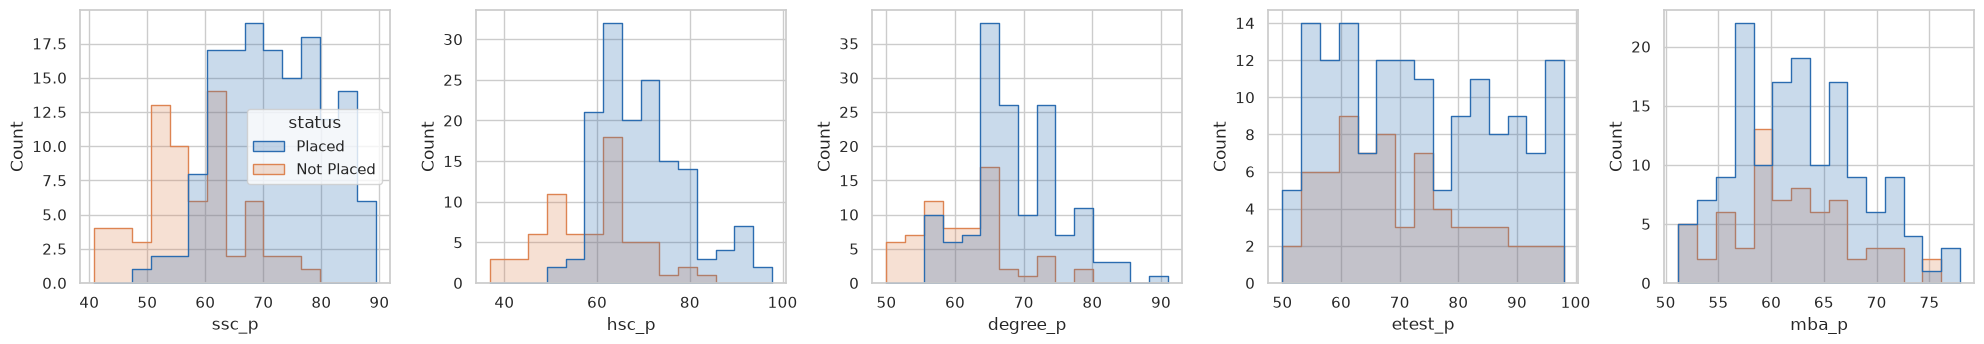

In [5]:
fig, axes = plt.subplots(1, 5, figsize=(20, 3.6))
for ax, col in zip(axes, NUMERIC_FEATURES):
    sns.histplot(
        data=raw, x=col, hue="status", hue_order=["Placed", "Not Placed"],
        palette=[BLUE, ORANGE], bins=15, element="step", ax=ax,
        legend=(col == NUMERIC_FEATURES[0]),
    )
    ax.set_xlabel(col)
plt.tight_layout()
plt.show()

Placed students tend to have higher 10th, 12th and degree marks. The two groups overlap heavily on the employability test (`etest_p`) and MBA % (`mba_p`).

### Categories

Share of students placed in each group. The dashed line is the overall placement rate, and `n` is the group size, which matters because some groups are tiny.

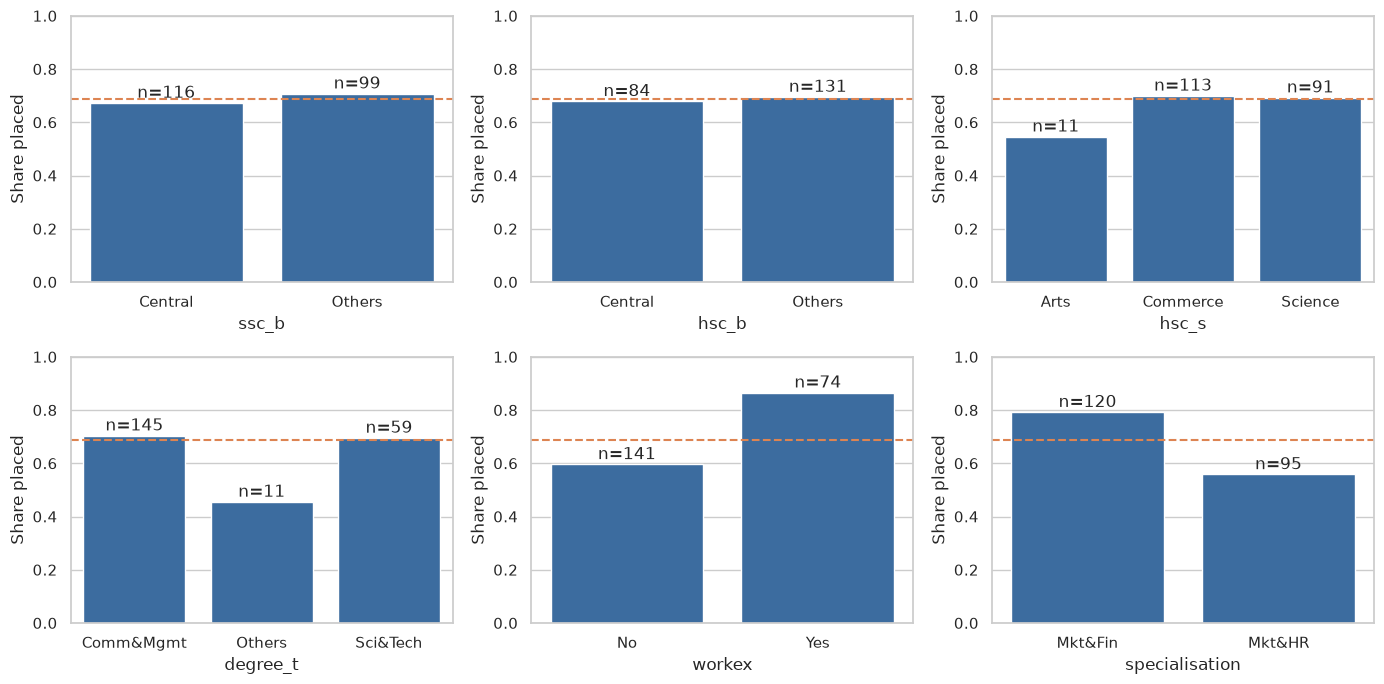

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.flat, CATEGORICAL_FEATURES):
    g = raw.groupby(col)["status"].agg(rate=lambda s: (s == "Placed").mean(), n="size").reset_index()
    sns.barplot(data=g, x=col, y="rate", color=BLUE, ax=ax)
    ax.axhline(baseline, ls="--", color=ORANGE)
    for i, r in g.iterrows():
        ax.text(i, r["rate"] + 0.02, f"n={int(r['n'])}", ha="center")
    ax.set_ylim(0, 1)
    ax.set_ylabel("Share placed")
plt.tight_layout()
plt.show()

Work experience and MBA specialisation show the clearest gaps. Groups with a handful of students (12th-grade Arts, degree field "Others", both n=11) are too small to read much into.

### Correlation between the percentages

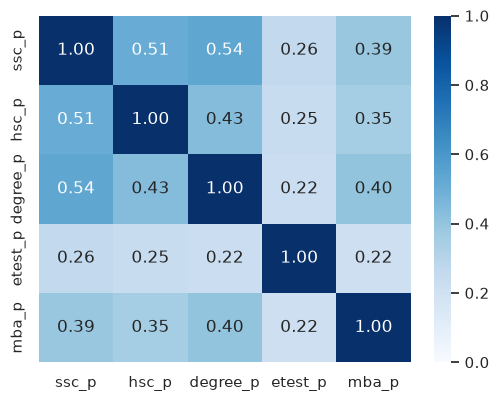

Strongest correlation between two inputs: 0.54


In [7]:
corr = raw[NUMERIC_FEATURES].corr()
plt.figure(figsize=(6, 4.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1)
plt.show()
off_diag = corr.to_numpy().copy()
np.fill_diagonal(off_diag, 0)
print(f"Strongest correlation between two inputs: {off_diag.max():.2f}")

The school and degree percentages are moderately correlated (up to about 0.5) but nowhere near redundant. The overlap does matter later, when we interpret coefficients.

I did **not** delete "outliers". The earlier version of this notebook dropped three students with a 12th-grade mark of 95%+ or a degree mark of 90%+. Those are legitimate values, and deleting rows from a 215-row dataset should need a better reason than looking extreme on a box plot.

## 3. Comparing models

Every candidate is the same pipeline (standardise the percentages, one-hot encode the categories) followed by a different classifier. Each is scored with 5-fold cross-validation repeated 10 times.

In [8]:
X, y = load_data()
cv = RepeatedStratifiedKFold(n_splits=CV_FOLDS, n_repeats=CV_REPEATS, random_state=RANDOM_STATE)

results = []
for name, model in candidate_models().items():
    scores = cross_validate(build_pipeline(model), X, y, cv=cv, scoring=SCORING)
    row = {"model": name}
    for metric in SCORING:
        row[f"{metric}_mean"] = scores[f"test_{metric}"].mean()
        row[f"{metric}_std"] = scores[f"test_{metric}"].std()
    results.append(row)

results = pd.DataFrame(results)
results[["model", "accuracy_mean", "accuracy_std", "f1_mean", "roc_auc_mean"]].round(3)

,model,accuracy_mean,accuracy_std,f1_mean,roc_auc_mean
0,Logistic regression,0.866,0.049,0.905,0.937
1,Gaussian naive Bayes,0.805,0.050,0.860,0.861
2,Linear SVM,0.869,0.043,0.906,0.935
3,RBF SVM,0.842,0.046,0.891,0.917
4,Random forest,0.852,0.047,0.897,0.919


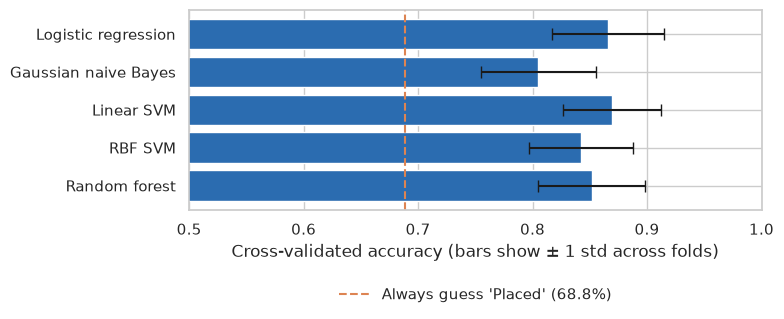

In [9]:
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.barh(results["model"], results["accuracy_mean"], xerr=results["accuracy_std"], color=BLUE, capsize=4)
ax.axvline(baseline, ls="--", color=ORANGE, label=f"Always guess 'Placed' ({baseline:.1%})")
ax.set_xlim(0.5, 1)
ax.invert_yaxis()
ax.set_xlabel("Cross-validated accuracy (bars show ± 1 std across folds)")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.32), frameon=False)
plt.tight_layout()
plt.show()

Logistic regression, the linear SVM, the RBF SVM and the random forest all land between about 84% and 87%, and the spread between folds (about ±4 to 5 points) is larger than the gaps between them. Gaussian naive Bayes is the only model that is clearly behind.

The earlier version of this notebook declared SVM the winner because it scored 89.7% against 87.2% for logistic regression on one 39-student test set. That gap is **one student**. Cross-validation shows the two are tied.

### Choosing between tied models

When several models are statistically indistinguishable, take the simplest. Concretely: the simplest model whose mean accuracy is within one standard error (`std / sqrt(folds)`) of the best. That is also the model that gives calibrated probabilities and readable coefficients, which the app uses.

In [10]:
chosen = choose_model(results.to_dict("records"))
print("Chosen model:", chosen)

Chosen model: Logistic regression


### Should `gender` be a feature?

The dataset includes gender, and the original notebook used it. Does it help?

In [11]:
X_with_gender = load_raw()[[*FEATURES, "gender"]]
rows = []
for name, model in [("Logistic regression", LogisticRegression(max_iter=1000)),
                    ("Linear SVM", SVC(kernel="linear"))]:
    without = cross_val_score(build_pipeline(model), X, y, cv=cv)
    with_g = cross_val_score(
        build_pipeline(model, categorical=[*CATEGORICAL_FEATURES, "gender"]), X_with_gender, y, cv=cv
    )
    rows.append({"model": name, "with gender": with_g.mean(), "without gender": without.mean(),
                 "difference": with_g.mean() - without.mean(), "fold std": without.std()})
pd.DataFrame(rows).round(3)

,model,with gender,without gender,difference,fold std
0,Logistic regression,0.872,0.866,0.006,0.049
1,Linear SVM,0.877,0.869,0.008,0.043


Adding gender changes accuracy by less than one point (0.6 to 0.8), far inside the fold-to-fold noise of about 4 to 5 points. A tool that scores individual students should not lean on a protected attribute for no measurable gain, so the final model leaves it out.

## 4. How good is the chosen model?

Out-of-fold predictions: each student is scored by a model that was trained *without* that student.

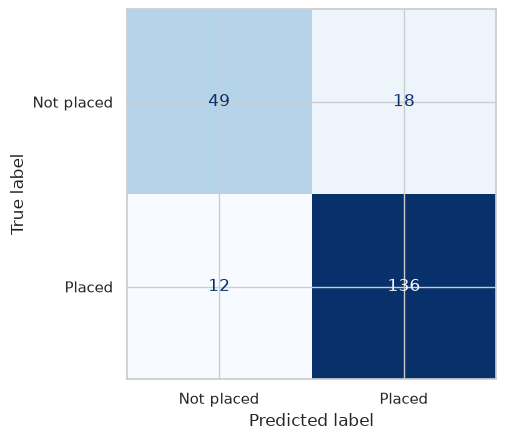

              precision    recall  f1-score   support

  Not placed       0.80      0.73      0.77        67
      Placed       0.88      0.92      0.90       148

    accuracy                           0.86       215
   macro avg       0.84      0.83      0.83       215
weighted avg       0.86      0.86      0.86       215



In [12]:
oof = cross_val_predict(
    build_pipeline(candidate_models()[chosen]), X, y,
    cv=StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE),
    method="predict_proba",
)[:, 1]
pred = (oof >= 0.5).astype(int)

ConfusionMatrixDisplay.from_predictions(
    y, pred, display_labels=["Not placed", "Placed"], cmap="Blues", colorbar=False
)
plt.show()
print(classification_report(y, pred, target_names=["Not placed", "Placed"]))

The model finds placed students more reliably than unplaced ones. Recall is about 92% for "Placed" but only about 73% for "Not placed", which is common when one class is much smaller.

## 5. What is the model using?

Coefficients of the final logistic regression, refit on all students. Percentages are standardised, so a coefficient is the change in log-odds per one standard deviation. Category coefficients are per 0/1 indicator, so they are not directly comparable with the numeric ones.

Because 215 students is small, I also refit on 300 bootstrap resamples and show the 95% interval for each coefficient. Intervals that cross zero are not distinguishable from "no effect".

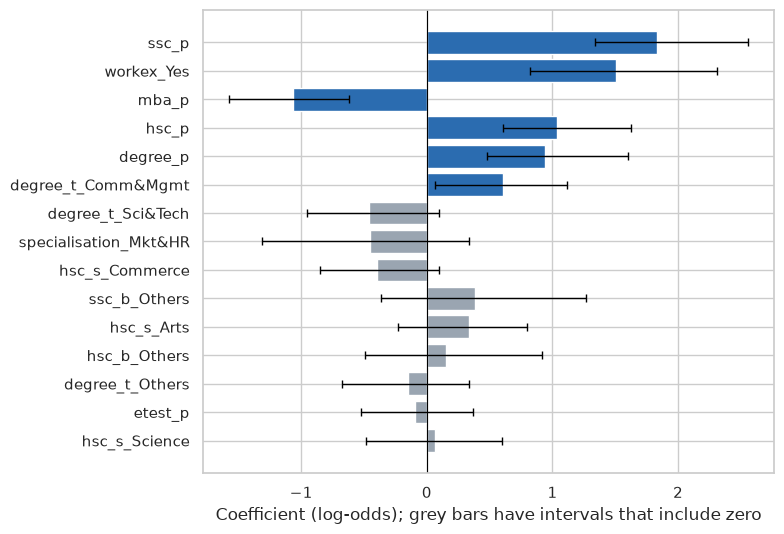

In [13]:
final = fit_final(chosen)
names = final.named_steps["prep"].get_feature_names_out()
coef = pd.Series(final.named_steps["model"].coef_[0], index=names)

rng = np.random.default_rng(0)
boot = []
for _ in range(300):
    idx = rng.integers(0, len(X), len(X))
    p = build_pipeline(LogisticRegression(max_iter=1000)).fit(X.iloc[idx], y.iloc[idx])
    boot.append(p.named_steps["model"].coef_[0])
boot = pd.DataFrame(boot, columns=names)
ci = pd.DataFrame({"coef": coef, "lo": boot.quantile(0.025), "hi": boot.quantile(0.975)})
ci = ci.reindex(ci["coef"].abs().sort_values().index)

fig, ax = plt.subplots(figsize=(8, 5.5))
colors = [BLUE if not (lo <= 0 <= hi) else "#9aa5b1" for lo, hi in zip(ci["lo"], ci["hi"])]
ax.barh(ci.index.str.replace(r"^(num|cat)__", "", regex=True), ci["coef"], color=colors)
ax.errorbar(ci["coef"], range(len(ci)), xerr=[ci["coef"] - ci["lo"], ci["hi"] - ci["coef"]],
            fmt="none", ecolor="black", capsize=3, lw=1)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("Coefficient (log-odds); grey bars have intervals that include zero")
plt.tight_layout()
plt.show()

**What stands out**

- 10th-grade %, work experience, 12th-grade % and degree % are the clear positive drivers: their intervals sit well above zero.
- **MBA % has a negative coefficient**, and the interval is entirely below zero. On its own, MBA % is only very weakly linked to placement (a slightly positive coefficient when it is the sole input). Once school and degree marks are held fixed, higher MBA % goes with *slightly lower* placement in this data.
- The employability test score and every category indicator other than work experience have intervals that include zero, apart from a Comm&Mgmt degree, which only just clears it. With this little data, the model cannot separate their effects from chance.

The MBA finding is stable across resamples, so it is a real pattern in these 215 students. But it is an association from a single campus with no obvious causal story, and it could easily be a quirk of who is in this dataset. It is **not** advice to score lower on the MBA.

## 6. Scoring one student

This is what the Streamlit app does behind the scenes. The contributions show how far each input moves the log-odds of placement compared with the average student.

In [14]:
student = X.iloc[[10]]
print(student.iloc[0].to_string(), end="\n\n")
print("Actual outcome:", "Placed" if y.iloc[10] == 1 else "Not placed")
print(f"Estimated chance of placement: {final.predict_proba(student)[0, 1]:.0%}\n")
explain_prediction(final, student, X).head(6).round(2)

ssc_p                  58.0
hsc_p                  61.0
degree_p               60.0
etest_p                62.0
mba_p                 60.85
ssc_b               Central
hsc_b               Central
hsc_s              Commerce
degree_t          Comm&Mgmt
workex                  Yes
specialisation       Mkt&HR

Actual outcome: Placed
Estimated chance of placement: 42%



,feature,contribution
0,Secondary school % (10th grade),-1.58
1,Work experience: Yes,0.99
2,Undergraduate degree %,-0.82
3,Higher secondary % (12th grade),-0.51
4,MBA %,0.26
5,MBA specialisation: Mkt&HR,-0.25


This student was chosen without looking at the result, and it happens to be a miss: they were placed, but the model gives only 42%. Their marks are all below average, and work experience only partly offsets that. Roughly one student in seven is misclassified like this (the out-of-fold accuracy is about 86%), which is a useful reminder of what an 87% model means in practice.

## 7. Conclusions and limits

- Cross-validated accuracy is about **87%**, against **69%** for always guessing "Placed". There is real signal in the academic record and work experience.
- Logistic regression, the linear SVM and the random forest cannot be told apart on this much data, so the simplest one is deployed. Naive Bayes is worse.
- The most useful inputs are 10th-grade %, work experience, 12th-grade % and degree %.
- Treat any accuracy figure as good to roughly **±5 points**. Small groups (12th-grade Arts, degree field "Others") barely constrain the model at all.
- The data comes from one campus. The model has not been tested on other institutions, years or programmes, and it captures correlation, not what would happen if a student changed something.
- Do not use this for admissions, hiring or any decision about a real person.

To retrain and refresh the saved model and metrics that the app loads:

```bash
python -m placement.train
```